In [1]:
%%capture
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
from data_loading    import load_data
from elo_ratings     import compute_elo
from player_profiles import compute_player_profiles
from h2h             import compute_h2h
from features        import build_dataset, ALL_FEATURES
from training        import train_all_models, evaluate, baseline_rank, \
                            plot_results, plot_feature_importance, leakage_diagnostic
from predict         import predict_matchup
raw      = load_data()
elo_df   = compute_elo(raw)
profiles = compute_player_profiles(raw)
h2h      = compute_h2h(raw)
df       = build_dataset(raw, profiles, h2h, elo_df)

trained, X_train, X_test, y_train, y_test = train_all_models(df)

baseline_auc, baseline_prob = baseline_rank(X_test, y_test)
results = [evaluate(name, model, X_test, y_test) for name, model in trained.items()]

In [3]:
# Determine our baseline metric (Only using ATP rank variable for prediction)

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import numpy as np

rd   = X_test["rank_diff"].fillna(0).values
prob = 1 / (1 + np.exp(rd / 100))
pred = (prob >= 0.5).astype(int)

auc   = roc_auc_score(y_test, prob)
acc   = (pred == y_test).mean()
ll    = log_loss(y_test, prob)
brier = brier_score_loss(y_test, prob)

print("=" * 45)
print("  BASELINE — rank difference only")
print("=" * 45)
print(f"  AUC          : {auc:.4f}")
print(f"  Accuracy     : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Log Loss     : {ll:.4f}")
print(f"  Brier Score  : {brier:.4f}")
print(f"\n  Better-ranked player wins : "
      f"{((X_test['rank_diff'] < 0) & (y_test == 1) | (X_test['rank_diff'] > 0) & (y_test == 0)).mean()*100:.1f}% of matches")

best_auc = max(r["auc"] for r in results)
best_name = max(results, key=lambda r: r["auc"])["name"]
print(f"\n  Best model   : {best_name} — AUC {best_auc:.4f}")
print(f"  Gain over baseline : +{best_auc - auc:.4f} AUC")

  BASELINE — rank difference only
  AUC          : 0.6884
  Accuracy     : 0.6571  (65.7%)
  Log Loss     : 0.6690
  Brier Score  : 0.2283

  Better-ranked player wins : 65.5% of matches

  Best model   : XGBoost — AUC 0.7164
  Gain over baseline : +0.0280 AUC


In [4]:
# Data Leakage Diagnostic

best_model = trained.get("XGBoost") or list(trained.values())[0]

diff_cols = [c for c in X_test.columns if c.endswith("_diff")]
X_inv = X_test.copy()
X_inv[diff_cols] *= -1
y_inv = 1 - y_test

auc_n = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
auc_i = roc_auc_score(y_inv,  best_model.predict_proba(X_inv)[:,1])

print(f"AUC normal   : {auc_n:.4f}")
print(f"AUC inverted : {auc_i:.4f}")
print(f"Difference   : {abs(auc_n - auc_i):.4f}")
print("No mirror leakage" if abs(auc_n - auc_i) < 0.02 else "AY CARAMBA")

AUC normal   : 0.7164
AUC inverted : 0.7194
Difference   : 0.0030
No mirror leakage


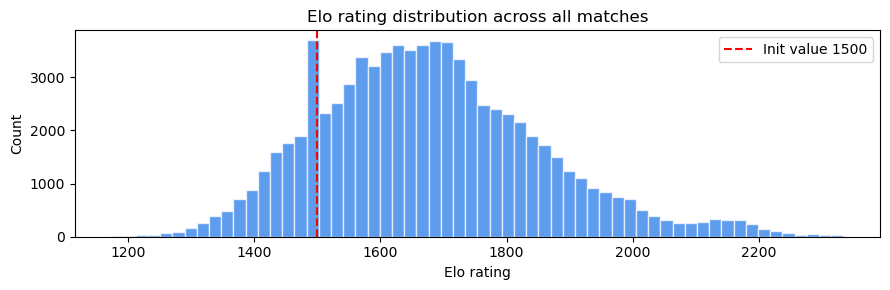

Min Elo : 1174
Max Elo : 2334
Mean Elo: 1678


In [5]:
# Elo Distribution 

import matplotlib.pyplot as plt

elo_vals = list(elo_df["winner_elo"]) + list(elo_df["loser_elo"])
plt.figure(figsize=(9, 3))
plt.hist(elo_vals, bins=60, color="#1a73e8", alpha=0.7, edgecolor="white")
plt.axvline(1500, color="red", lw=1.5, linestyle="--", label="Init value 1500")
plt.xlabel("Elo rating")
plt.ylabel("Count")
plt.title("Elo rating distribution across all matches")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min Elo : {min(elo_vals):.0f}")
print(f"Max Elo : {max(elo_vals):.0f}")
print(f"Mean Elo: {np.mean(elo_vals):.0f}")